# Method B 네트워크 walk-EDA

> 목적: ① 탐색 walk **스텝수 결정**(드리프트 진단) ② **트렌드 키워드 비율** 성공/실패 비교
> ③ **중심성 허브 키워드** ④ 허브 포함이 성공/실패에 따라 다른지.
> 모델: exp10 (`serve.SERVING_EXP`), 오프라인 parquet 기반.

## Phase 0. 셋업

In [1]:
import os, sys
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
import networkx as nx
_anchor = Path(globals().get("__vsc_ipynb_file__", ".")).resolve().parent if globals().get("__vsc_ipynb_file__") else Path.cwd()
ROOT = next((str(p) for p in [_anchor, *_anchor.parents] if (p / "CLAUDE.md").exists()), str(_anchor))
sys.path.insert(0, ROOT); os.chdir(ROOT)
matplotlib.rcParams["font.family"] = "Malgun Gothic"; matplotlib.rcParams["axes.unicode_minus"] = False

from src.eval import serve
D = serve._data()
kn = pd.read_parquet("data/processed/hin/keyword_nodes.parquet")
TREND_KW = set(kn.loc[kn["is_trend_keyword"], "keyword"])
prod_succ = dict(zip(D["scores"]["ITEM_NM"], D["scores"]["y_true"]))
SUCC = [p for p in D["prod2kw"] if prod_succ.get(p) == 1]
FAIL = [p for p in D["prod2kw"] if prod_succ.get(p) == 0]
KW_OF = {p: set(k for k, _ in lst) for p, lst in D["prod2kw"].items()}  # 제품→키워드집합
SEEDS = [s for s in ["마라", "흑임자", "로제", "단백질", "딸기", "띠부씰", "감자", "매콤"] if s in D["graph_kw"]]
print("모델:", serve.SERVING_EXP, "| 성공", len(SUCC), "/ 실패", len(FAIL), "| 트렌드키워드", len(TREND_KW))
print("시드:", SEEDS)


모델: exp18_multihop_1attn | 성공 1197 / 실패 3835 | 트렌드키워드 354
시드: ['마라', '흑임자', '로제', '단백질', '딸기', '띠부씰', '감자', '매콤']


## Phase 1-0. 킬러(Killer) / 지뢰(Landmine) 키워드 기준 확정

> 두 버전의 성공 지향(C3) 및 노이즈(C6) 지표를 동일한 잣대로 공정하게 평가하기 위해, 기준이 되는 **킬러(성공 기여) 키워드**와 **지뢰(실패 유발) 키워드**를 먼저 추출하고 검증하여 확정합니다.
> 아래 코드 셀에서 자동으로 추출된 키워드 목록을 보고 수동으로 추가/제외 조정할 수 있습니다.

In [3]:
# ── 킬러/지뢰 키워드 기준 자동 추출 및 수동 확정 ──
import experiments.walk_compare as wc

# 1. 장부 추출 기준 버전 및 파라미터 설정
BASE_EXP_NAME = "exp22_2hop_kw3"
LEDGER_TOP_PCT = 20.0   # 상위/하위 % 범위
MIN_SUPPORT = 3        # 최소 등장 제품 수 (오버핏 방지)

base_D = wc.load_version(BASE_EXP_NAME)
scores, auto_killer, auto_landmine = wc.build_ledger(base_D, top_pct=LEDGER_TOP_PCT, min_support=MIN_SUPPORT)

# 2. 수동 조정 (Override) — 필요 시 튜닝 결과에 따라 추가/제거
REMOVE_FROM_KILLER = set()   # 킬러에서 제외할 단어 (예: {'특정브랜드'})
ADD_TO_KILLER = set()        # 킬러에 강제로 추가할 단어

REMOVE_FROM_LANDMINE = set() # 지뢰에서 제외할 단어
ADD_TO_LANDMINE = set()      # 지뢰에 강제로 추가할 단어

# 최종 확정
KILLER_KWS = (set(auto_killer) - REMOVE_FROM_KILLER) | ADD_TO_KILLER
LANDMINE_KWS = (set(auto_landmine) - REMOVE_FROM_LANDMINE) | ADD_TO_LANDMINE

print(f"=== 킬러 키워드 확정 ({len(KILLER_KWS)}개, 기준: {BASE_EXP_NAME}) ===")
print(sorted(list(KILLER_KWS)))
print(f"\n=== 지뢰 키워드 확정 ({len(LANDMINE_KWS)}개, 기준: {BASE_EXP_NAME}) ===")
print(sorted(list(LANDMINE_KWS)))

=== 킬러 키워드 확정 (262개, 기준: exp22_2hop_kw3) ===
['2+2', '2026', 'KBO', 'K리그', 'PEACEMINUSONE', 'PLAVE', 'T1', 'TXT', '가나', '가나디', '가매', '가을', '건더기', '게', '경기장', '고구마', '고창', '공룡', '관람', '광천', '구운', '군', '그래놀라', '그린티', '그릴리', '깐풍기', '깔라만시', '껌', '꼬깔콘', '꿀', '난', '너구리', '녹음', '녹진함', '누네띠네', '누들', '다이스', '단', '닭갈비', '당면', '대게', '더킹', '덕개', '데이', '데이지', '도쿄', '드럼스틱', '디진다 돈까스', '딥', '딥앤로우', '딱지장', '땡초', '뚱카롱', '띠부씰', '라더', '라이트', '랑그드샤', '레드벨벳', '로스', '로코모코', '롤케이크', '마파', '말랑함', '말이', '맛자랑', '맛장우', '망고', '망그러진곰', '맥스봉', '머핀', '메밀', '메이플', '메타몽', '멸균', '명란', '명장', '모나카', '몰리두커', '무스', '묵직함', '미각', '미노리', '미노리키친', '미미미누', '미역', '바른목장', '바밤바', '박은영', '박카스', '반숙', '발효', '밥도둑', '배', '버블', '버섯', '베노프', '베지', '벽돌', '별', '보름달', '볼케이노', '뵈르뵈르', '부드러움', '부르봉', '부창제과', '브레드', '브롤스타즈', '비건', '비타민', '빈츠', '빼빼로', '뻥이요', '뿌셔뿌셔', '사브레', '삼립', '생크림', '소금', '소보로', '솔트', '송이', '쇼콜라', '수험생', '슈거', '슈퍼셀', '스노우', '스웨디시', '스타', '스타벅스', '스팀', '슴슴함', '시그니처', '시즌', '식감', '쌉싸름함', '쑥', '아침', '안심', '안유성', '알리오올리오', '알밤'

## Phase 1. 두 버전 비교 및 최종 채택 (기존 Phase F)

> 엣지값 높은 경로(K-P-K)로 조합 생성 시 **"좋은 네트워크"인지** 두 버전을 대조해 최종 1개를 채택.
> 모듈: `experiments/walk_compare.py` (serve 서빙 백엔드는 안 건드림, 버전별 export 직접 로드).
>
> **[1] 전처리**: ① deg 상위 HUB_PCT% **허브 마스킹**(무색무취 토큰 선제외) ② **킬러/지뢰 장부** — `score(k)=성공제품보유/전체보유`, 상위 LEDGER_TOP_PCT% 킬러·하위 LEDGER_TOP_PCT% 지뢰.
>
> **[2] 정성 기준**:
> - C1 일관성(조합쌍 동시출현↑) / C2 구체성(deg·허브비율↓) / **C3 성공지향(킬러↑·지뢰↓·경유 success↑)** / C4 트렌드 / C6 노이즈(지뢰·파편↓)
> - Rule A 카테고리 앵커(라면·젤리 등 1차명사 ≥1) / Rule B base:trend 밸런스(트렌드 30~40%)
>
> **핵심 질문(F3)**: ip≥1로 IP 엣지를 1만개로 늘리면 → **IP 다양성 확보**(킬러 유지+다양성↑)인가, **노이즈 드리프트**(지뢰↑·일관성↓)인가?

In [5]:
# Phase F0 — 두 버전 로드 + 허브 마스킹 + 공통 킬러/지뢰 장부 연동
import importlib, pandas as pd, numpy as np
import experiments.walk_compare as wc
importlib.reload(wc)
from src.data_builder.build_hetero_data import norm_id

# 수치 조정 파라미터 (여기서 미세조정)
HUB_PCT = 5.0          # 허브 마스킹 비율 (상위 %)

TREND_F = wc.load_trend_kw()
_trend = pd.read_parquet(wc.TREND_PATH)
TREND_ATTRS = {str(t): list(a) for t, a in zip(_trend["트렌드_키워드"], _trend["추출_속성_final"])}

VERS_NAMES = {"exp22(ip≥2)": "exp22_2hop_kw3", "exp31(ip≥1)": "exp31_2hop_kw3_ip1"}
DV, LEDG, VERSIONS = {}, {}, {}
for tag, name in VERS_NAMES.items():
    D = wc.load_version(name)
    D["hub"] = wc.build_hub_mask(D, pct=HUB_PCT)
    D["stop"] = wc.BASE_STOP | D["hub"]
    DV[tag], VERSIONS[tag] = D, (D, D["stop"])
    
    # 1-0단계에서 확정한 공통 킬러/지뢰 키워드로 장부 강제 연동 (정량 지표의 공정한 잣대 마련)
    v_scores, _, _ = wc.build_ledger(D, top_pct=LEDGER_TOP_PCT, min_support=MIN_SUPPORT)
    LEDG[tag] = (v_scores, KILLER_KWS, LANDMINE_KWS)
    print(f"{tag}: 키워드 {len(D['graph_kw'])} | 허브 {len(D['hub'])} | 킬러(공통) {len(KILLER_KWS)} / 지뢰(공통) {len(LANDMINE_KWS)}")

# IP 보유 제품명 (F3 시드)
_pe = pd.read_parquet(f"{wc.HIN_DIR}/product_ip_edges.parquet")
_pn = pd.read_parquet(f"{wc.HIN_DIR}/product_nodes.parquet")
_id2nm = {norm_id(c): str(n) for c, n in zip(_pn["ITEM_CD"], _pn["ITEM_NM"])}
_ip_names = {_id2nm.get(norm_id(c)) for c in _pe["ITEM_CD"]}
IP_PRODUCTS = sorted(p for p in _ip_names if p and p in DV["exp22(ip≥2)"]["prod2kw"])
SEEDS_F = ["마라", "흑임자", "로제", "딸기", "띠부씰", "산리오", "단백질"]
print(f"IP 보유 제품(F3 시드): {len(IP_PRODUCTS)}")
print("킬러 예 (공통):", list(KILLER_KWS)[:8])
print("지뢰 예 (공통):", list(LANDMINE_KWS)[:8])

exp22(ip≥2): 키워드 2371 | 허브 121 | 킬러(공통) 262 / 지뢰(공통) 262
exp31(ip≥1): 키워드 2371 | 허브 121 | 킬러(공통) 262 / 지뢰(공통) 262
IP 보유 제품(F3 시드): 1050
킬러 예 (공통): ['프로즌', '로코모코', '미노리', '응원', '알싸함', '점심', '메밀', '커스터드']
지뢰 예 (공통): ['맥앤치즈', '파스텔', '삼계탕', '센쥬', '단짠', '랩', '씬', '귀리']


In [6]:
# Phase F1 — 조합 샘플 좌우 대조 (사람이 직관 비교)
print("=== F1. 동일 시드 → 두 버전 bundle/path 대조 ===")
_f1 = wc.f1_side_by_side(VERSIONS, SEEDS_F, TREND_ATTRS)
try:
    from IPython.display import display; display(_f1)
except Exception:
    print(_f1.to_string(index=False))

=== F1. 동일 시드 → 두 버전 bundle/path 대조 ===


,시드,[exp22(ip≥2)] 묶음,[exp22(ip≥2)] 경로,[exp31(ip≥1)] 묶음,[exp31(ip≥1)] 경로
0,마라,마라 · 곤약 · 중식 · 자극적 · 닭가슴살 · 가슴,마라 → 곤약 → 닭가슴살 → 가슴,마라 · 곤약 · 중식 · 자극적 · 닭가슴살 · 가슴,마라 → 곤약 → 초 → 비빔
1,흑임자,흑임자 · 알 · 묵직함 · 공룡 · 픽셀리 · 잠뜰,흑임자 → 알 → 묵직함 → 이정후,흑임자 · 공룡 · 잠뜰 · 픽셀리 · 후르츠 · 소보로,흑임자 → 공룡 → 잠뜰 → 픽셀리
2,로제,로제 · 떡볶이 · 분식 · 볶이 · 히밥 · 어묵,로제 → 떡볶이 → 분식 → 어묵,로제 · 떡볶이 · 분식 · 어묵 · 히밥 · 국밥,로제 → 떡볶이 → 분식 → 어묵
3,딸기,딸기 · 헬로키티 · 말랑함 · 모찌 · 롤 · 페스츄리,딸기 → 헬로키티 → 말랑함 → 망고,딸기 · 헬로키티 · 페스츄리 · 모찌 · 베이크하우스405 · 베이크,딸기 → 헬로키티 → 페스츄리 → 오징어
4,띠부씰,띠부씰 · 관람 · 초특가 · K리그 · 응원 · 스포츠,띠부씰 → 관람 → 초특가 → K리그,띠부씰 · 응원 · 초특가 · K리그 · 관람 · 스포츠,띠부씰 → 응원 → 스포츠 → 초특가
5,산리오,산리오 · 빼빼로 · 테디베어 · 아몬드 · 깔끔 · 빼빼로데이,산리오 → 빼빼로 → 아몬드 → 견과류,산리오 · 빼빼로 · 아몬드 · 테디베어 · 깔끔 · 빼빼로데이,산리오 → 빼빼로 → 아몬드 → 견과류
6,단백질,단백질 · 프로틴 · 이정후 · 견과류 · 아몬드 · 띠부씰,단백질 → 프로틴 → 이정후 → 띠부씰,단백질 · 프로틴 · 이정후 · 띠부씰 · 응원 · 초특가,단백질 → 프로틴 → 이정후 → 띠부씰


In [7]:
# Phase F2 — 정량 지표 (C1~C6 + Rule A/B), 시드 평균
print("=== F2. 정량 지표 비교 ===")
_f2 = wc.f2_quant_table(VERSIONS, SEEDS_F, TREND_ATTRS, TREND_F, LEDG)
try:
    from IPython.display import display; display(_f2)
except Exception:
    print(_f2.to_string())
print("\n해석: C1 일관성↑·C3 경유성공도↑·C3 킬러↑·지뢰↓·C6 노이즈↓ = 좋은 네트워크")
print("      RuleA 앵커충족·RuleB 밸런스충족 높을수록 '기획서 작성 가능한' 조합")

=== F2. 정량 지표 비교 ===


,exp22(ip≥2),exp31(ip≥1)
C1_일관성,3.381,3.019
C2_평균deg,32.381,29.595
C2_허브비율,0.048,0.048
C3_킬러비율,0.381,0.429
C3_지뢰비율,0.000,0.000
C3_경유성공도,0.800,0.765
C4_트렌드비율,0.310,0.286
C6_노이즈비율,0.000,0.000
RuleA_앵커충족,0.143,0.143
RuleB_밸런스충족,0.143,0.571



해석: C1 일관성↑·C3 경유성공도↑·C3 킬러↑·지뢰↓·C6 노이즈↓ = 좋은 네트워크
      RuleA 앵커충족·RuleB 밸런스충족 높을수록 '기획서 작성 가능한' 조합


In [8]:
# Phase F3 — IP 경유 분석 (두 버전 핵심 차이 판정)
print("=== F3. IP 보유 제품 시드 → 조합 다양성·품질 ===")
_f3 = wc.f3_ip_analysis(VERSIONS, IP_PRODUCTS, TREND_ATTRS, TREND_F, LEDG, n_sample=300)
try:
    from IPython.display import display; display(_f3)
except Exception:
    print(_f3.to_string())
print("\n판정: ip≥1(exp31)이 [다양성↑ & 킬러 유지 & 지뢰↓] → IP 다양성 확보(채택 근거)")
print("      [지뢰↑ or 일관성↓ or 동일조합 반복(다양성↓)] → 노이즈 드리프트(exp22 유지)")

=== F3. IP 보유 제품 시드 → 조합 다양성·품질 ===


,exp22(ip≥2),exp31(ip≥1)
생성 조합수,296.000,296.000
고유키워드 다양성,0.370,0.373
평균 킬러비율,0.289,0.298
평균 지뢰비율,0.061,0.059
평균 일관성(C1),2.000,1.900



판정: ip≥1(exp31)이 [다양성↑ & 킬러 유지 & 지뢰↓] → IP 다양성 확보(채택 근거)
      [지뢰↑ or 일관성↓ or 동일조합 반복(다양성↓)] → 노이즈 드리프트(exp22 유지)


## Phase F4 — 최종 결정표 (수기)

각 기준별 두 버전 점수(F1~F3 출력) 기입 후 우세 표시.

| 기준 | exp22 (ip≥2) | exp31 (ip≥1) | 우세 |
|---|---|---|---|
| C1 일관성 | | | |
| C2 구체성 (deg·허브) | | | |
| C3 성공지향 (킬러↑·지뢰↓·경유성공↑) | | | |
| C4 트렌드 비율 | | | |
| C6 노이즈 비율 | | | |
| Rule A 카테고리 앵커 | | | |
| Rule B base:trend 밸런스 | | | |
| **F3 IP 다양성·품질** ★ | | | |

### ✅ 최종 채택: ________________  (이 버전으로 serving export → walk 시각화)

- **라벨 기준(PR-AUC)**: exp22 **0.6852** > exp31 0.6753 → 라벨은 exp22 우세.
- **정성 채택 근거** (라벨을 뒤집을 만한 추천 품질 차이가 있으면 기입):
- **결정**: PR-AUC·정성 둘 다 exp22면 exp22 / F3에서 exp31의 IP 다양성이 의미있게 우수하면 재고.

## Phase 2-1. walk 분석 — 일관묶음 vs 탐색경로, 스텝수 드리프트 (기존 Phase A)

선택된 최종 모델 버전을 기준으로 walk 심층 분석을 진행합니다.

In [2]:
# ── Phase 2. 최종 채택된 모델로 메인 분석 환경 전환 ──
# F4 최종 채택 결과에 따라 아래 CHOSEN_EXP 값을 변경하여 메인 분석 대상을 설정하세요.
CHOSEN_EXP = "exp22_2hop_kw3"  # 예: 'exp22_2hop_kw3' (ip≥2) 또는 'exp31_2hop_kw3_ip1' (ip≥1)

import src.eval.serve as serve
serve.SERVING_EXP = CHOSEN_EXP
serve._data.cache_clear()  # 기존 캐시 초기화

# 데이터셋 재로드 및 분석용 전역변수 업데이트
import pandas as pd
kn = pd.read_parquet("data/processed/hin/keyword_nodes.parquet")
TREND_KW = set(kn.loc[kn["is_trend_keyword"], "keyword"])
D = serve._data()
prod_succ = dict(zip(D["scores"]["ITEM_NM"], D["scores"]["y_true"]))
SUCC = [p for p in D["prod2kw"] if prod_succ.get(p) == 1]
FAIL = [p for p in D["prod2kw"] if prod_succ.get(p) == 0]
KW_OF = {p: set(k for k, _ in lst) for p, lst in D["prod2kw"].items()}
SEEDS = [s for s in ["마라", "흑임자", "로제", "단백질", "딸기", "띠부씰", "감자", "매콤"] if s in D["graph_kw"]]

print(f"[임포트 완료] 분석용 메인 모델이 '{serve.SERVING_EXP}'로 전환되었습니다.")
print(f"성공 제품: {len(SUCC)}개 | 실패 제품: {len(FAIL)}개 | 트렌드키워드: {len(TREND_KW)}개\n")

# ── Phase A. walk 분석: 일관묶음 vs 탐색경로, 스텝수 드리프트 진단 ──
print("① 일관 묶음(bundle) vs ② 탐색 경로(paths) — 스텝별\n")
for seed in SEEDS[:4]:
    attrs = serve.infer_attrs(seed) or [seed]
    bundle = serve.recommend_bundle(attrs)
    print(f"[{seed}] 묶음: {bundle}")
    for st in [2, 3, 4]:
        ps = serve.recommend_paths(attrs, max_steps=st, n_paths=2, avoid=bundle)
        for p, _ in ps:
            print(f"   {st}스텝: " + " → ".join(p))
    print()

# 드리프트 지표: 스텝별 경로 키워드의 (a)신규율 (b)평균 제품빈도(=일반성)
print("스텝별 드리프트 진단 (전 시드 평균):")
print(f"{'스텝':>4}{'신규키워드율':>12}{'평균 제품빈도':>13}  (빈도↑=일반어로 드리프트)")
for st in [2, 3, 4]:
    new_r, gen = [], []
    for seed in SEEDS:
        attrs = serve.infer_attrs(seed) or [seed]
        bundle = set(serve.recommend_bundle(attrs))
        for p, _ in serve.recommend_paths(attrs, max_steps=st, n_paths=3, avoid=list(bundle)):
            kws = p[1:]
            if kws:
                new_r.append(np.mean([k not in bundle for k in kws]))
                gen.append(np.mean([D["deg"].get(k, 0) for k in kws]))
    print(f"{st:>4}{np.mean(new_r):>12.2f}{np.mean(gen):>13.0f}")
print("→ 신규율 높고 빈도 적당하면 좋은 탐색 / 빈도 급증하면 일반어 드리프트 (스텝 줄일 신호)")


① 일관 묶음(bundle) vs ② 탐색 경로(paths) — 스텝별

[마라] 묶음: ['감칠맛', '마라', '매콤', '쫄깃함', '달콤', '고소']
   2스텝: 감칠맛 → 대게 → 딱지장
   2스텝: 감칠맛 → 경기장 → 관람
   3스텝: 감칠맛 → 개성 → 촉촉 → 도쿄
   3스텝: 감칠맛 → 경기장 → K리그 → 관람
   4스텝: 감칠맛 → 개성 → 촉촉 → 도쿄 → 브레드
   4스텝: 감칠맛 → 개성 → 매콤 → 관람 → 경기장

[흑임자] 묶음: ['간식', '견과류', '달콤', '고소', '부드러움', '바삭']
   2스텝: 간식 → 관람 → 경기장
   2스텝: 간식 → 도쿄 → 브레드
   3스텝: 간식 → 관람 → K리그 → 경기장
   3스텝: 간식 → 잠뜰 → 픽셀리 → 덕개
   4스텝: 간식 → 관람 → 초특가 → K리그 → 경기장
   4스텝: 간식 → 관람 → 경기장 → 콜라보 → 뵈르뵈르

[로제] 묶음: ['크림', '부드러움', '달콤', '빵', '고소', '촉촉']
   2스텝: 크림 → 연세우유 → 맘모스
   2스텝: 크림 → 연세우유 → 다이스
   3스텝: 크림 → 생크림 → 응원 → 경기장
   3스텝: 크림 → 구름 → 픽셀리 → 잠뜰
   4스텝: 크림 → 생크림 → 응원 → 관람 → 경기장
   4스텝: 크림 → 구름 → 픽셀리 → 잠뜰 → 공룡

[단백질] 묶음: ['단백질', '닭가슴살', '닭', '가슴', '부드러움', '달콤']
   2스텝: 단백질 → 베노프 → 청키
   2스텝: 단백질 → 프로틴 → 피쉬
   3스텝: 단백질 → 베노프 → 바 → 딥앤로우
   3스텝: 단백질 → 베노프 → 저당 → 딥앤로우
   4스텝: 단백질 → 베노프 → 달콤 → 홀릭 → 스타일
   4스텝: 단백질 → 베노프 → 달콤 → 홀릭 → 스웨디시

스텝별 드리프트 진단 (전 시드 평균):
  스텝      신규키워드율      평균 제품빈도  (빈도↑=일반어로 드리프트)
   2       

## Phase 2-2. 트렌드 키워드 비율 — 성공 vs 실패 (기존 Phase B)

,구분,트렌드KW 비율(전체),제품당 트렌드비율(평균),제품당 트렌드KW수
0,성공,0.556,0.557,5.13
1,실패,0.500,0.498,3.80



→ 성공/실패 트렌드비율 비율(lift) = 1.11  (>1이면 성공 제품이 트렌드 키워드를 더 많이 보유)


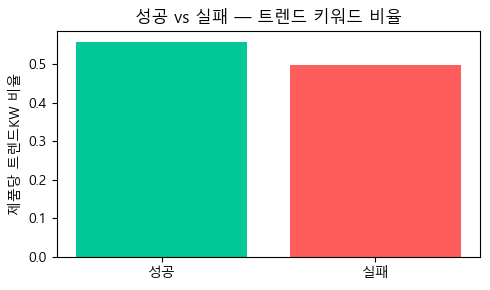

In [3]:
# ── Phase B. 성공/실패 제품 주변 키워드의 트렌드 키워드 비율 ──
def trend_stats(prods):
    tot, tr, per = 0, 0, []
    for p in prods:
        kws = [k for k, _ in D["prod2kw"][p]]
        if not kws:
            continue
        t = sum(k in TREND_KW for k in kws)
        tot += len(kws); tr += t; per.append(t / len(kws))
    return tr / max(tot, 1), float(np.mean(per)), float(np.mean([len([k for k,_ in D["prod2kw"][p] if k in TREND_KW]) for p in prods]))

sr, sp, sc = trend_stats(SUCC)
fr, fp, fc = trend_stats(FAIL)
df = pd.DataFrame({
    "구분": ["성공", "실패"],
    "트렌드KW 비율(전체)": [f"{sr:.3f}", f"{fr:.3f}"],
    "제품당 트렌드비율(평균)": [f"{sp:.3f}", f"{fp:.3f}"],
    "제품당 트렌드KW수": [f"{sc:.2f}", f"{fc:.2f}"],
})
try:
    from IPython.display import display; display(df)
except Exception:
    print(df.to_string(index=False))
print(f"\n→ 성공/실패 트렌드비율 비율(lift) = {sr/max(fr,1e-9):.2f}  (>1이면 성공 제품이 트렌드 키워드를 더 많이 보유)")
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["성공", "실패"], [sp, fp], color=["#00C896", "#FF5C5C"])
ax.set_ylabel("제품당 트렌드KW 비율"); ax.set_title("성공 vs 실패 — 트렌드 키워드 비율"); plt.tight_layout(); plt.show()


## Phase 2-3. 네트워크 허브 키워드 (중심성) (기존 Phase C)

In [4]:
# ── Phase C. 네트워크 허브 키워드 (중심성) ──
# 키워드 동시출현 그래프 (제품 매개) → degree / eigenvector 중심성
coc = defaultdict(int)
for p, lst in D["prod2kw"].items():
    ks = [k for k, _ in lst]
    for a in range(len(ks)):
        for b in range(a + 1, len(ks)):
            coc[tuple(sorted((ks[a], ks[b])))] += 1
G = nx.Graph()
for (a, b), w in coc.items():
    if w >= 3:                              # 노이즈 제거 임계
        G.add_edge(a, b, weight=w)
print(f"동시출현 그래프: 노드 {G.number_of_nodes()} / 엣지 {G.number_of_edges()}")

# 최대 연결요소에서 eigenvector 중심성
Gc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
eig = nx.eigenvector_centrality_numpy(Gc, weight="weight")
deg_c = {k: D["deg"].get(k, 0) for k in G.nodes}      # 제품빈도(인기 허브)
cooc_deg = dict(G.degree())                            # 연결 키워드 수(커넥터 허브)

def top(dct, n=15):
    return sorted(dct.items(), key=lambda x: -x[1])[:n]

print("\n[degree 허브 — 제품 많이 보유]:", [k for k, _ in top(deg_c, 10)])
print("[connector 허브 — 많은 키워드와 동시출현]:", [k for k, _ in top(cooc_deg, 10)])
print("[eigenvector 허브 — 중심부 연결]:", [k for k, _ in top(eig, 10)])
HUBS = [k for k, _ in top(eig, 30)]      # Phase D 에서 사용할 허브 집합 (eigenvector 기준)


동시출현 그래프: 노드 1176 / 엣지 11375

[degree 허브 — 제품 많이 보유]: ['간식', '달콤', '야식', '디저트', '부드러움', '고소', '식사', '초코', '크림', '빵']
[connector 허브 — 많은 키워드와 동시출현]: ['간식', '달콤', '야식', '부드러움', '식사', '디저트', '고소', '간편', '크림', '매콤']
[eigenvector 허브 — 중심부 연결]: ['간식', '달콤', '부드러움', '디저트', '고소', '야식', '크림', '초코', '바삭', '빵']


## Phase 2-4. 허브 포함 여부 — 성공 vs 실패 비교 (기존 Phase D)

,허브,성공포함율,실패포함율,lift,제품수
26,한정,0.085,0.018,4.74,171
23,시즌,0.094,0.025,3.74,208
13,촉촉,0.104,0.037,2.84,266
19,식감,0.088,0.032,2.76,227
2,부드러움,0.243,0.103,2.35,687
10,짭조름함,0.122,0.057,2.15,364
4,고소,0.185,0.089,2.07,563
24,새콤,0.063,0.031,2.06,194
20,딸기,0.072,0.036,2.01,223
16,쫀득함,0.084,0.047,1.79,282



제품당 평균 허브 키워드 수 — 성공 4.09 / 실패 2.58 (lift 1.58)
→ lift>1 이면 성공 제품이 허브 키워드를 더 많이 포함 = '허브 포함이 성공과 연관'


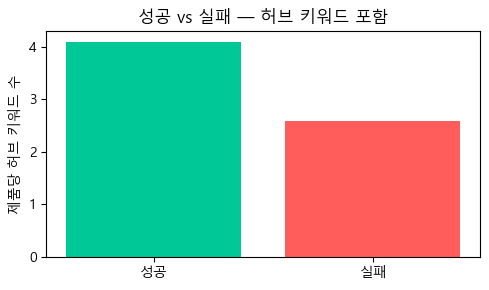

In [5]:
# ── Phase D. 허브 키워드 포함 여부 — 성공 vs 실패 비교 ──
succ_sets = [KW_OF[p] for p in SUCC]
fail_sets = [KW_OF[p] for p in FAIL]

rows = []
for h in HUBS:
    sf = np.mean([h in s for s in succ_sets])
    ff = np.mean([h in s for s in fail_sets])
    rows.append({"허브": h, "성공포함율": round(sf, 3), "실패포함율": round(ff, 3),
                 "lift": round(sf / (ff + 1e-9), 2), "제품수": D["deg"].get(h, 0)})
hub_df = pd.DataFrame(rows).sort_values("lift", ascending=False)
try:
    from IPython.display import display; display(hub_df.head(20))
except Exception:
    print(hub_df.head(20).to_string(index=False))

# 종합: 제품당 평균 허브 보유 수
hubset = set(HUBS)
s_hub = np.mean([len(s & hubset) for s in succ_sets])
f_hub = np.mean([len(s & hubset) for s in fail_sets])
print(f"\n제품당 평균 허브 키워드 수 — 성공 {s_hub:.2f} / 실패 {f_hub:.2f} (lift {s_hub/max(f_hub,1e-9):.2f})")
print("→ lift>1 이면 성공 제품이 허브 키워드를 더 많이 포함 = '허브 포함이 성공과 연관'")
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["성공", "실패"], [s_hub, f_hub], color=["#00C896", "#FF5C5C"])
ax.set_ylabel("제품당 허브 키워드 수"); ax.set_title("성공 vs 실패 — 허브 키워드 포함"); plt.tight_layout(); plt.show()


## Phase 2-5. 결론 (수기) (기존 Phase E)

### 1. walk 스텝수 (Phase 2-1)

### 2. 트렌드 키워드 (Phase 2-2)

### 3. 허브 키워드 (Phase 2-3·2-4)
